In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
listings = pd.read_csv(r"D:\a_PERSONAL\airbnb_data_engineering\data\processed\listings_clean.csv")
calendar = pd.read_csv(r"D:\a_PERSONAL\airbnb_data_engineering\data\processed\calendar_clean.csv")
reviews = pd.read_csv(r"D:\a_PERSONAL\airbnb_data_engineering\data\processed\reviews_clean.csv")

In [7]:
listings.shape

(35036, 90)

In [5]:
reviews.shape


(1003299, 6)

In [6]:
calendar.shape

(12788141, 5)

In [8]:
listings.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.503600e+04,3.503600e+04,0.0,3.503600e+04,3.419600e+04,0.0,34196.000000,34196.000000,34196.000000,34196.000000,...,24528.000000,24536.000000,24525.000000,24526.00000,0.0,35036.000000,35036.000000,35036.000000,35036.000000,24542.000000
mean,5.007097e+17,2.026041e+13,NaN,1.855502e+08,1.467166e+18,NaN,8.454264,5.587613,6.939554,5.417710,...,4.834390,4.818834,4.745455,4.63393,NaN,54.826008,46.960212,7.034935,0.073467,0.778935
std,5.815799e+17,0.000000e+00,NaN,2.041843e+08,1.219032e+16,NaN,3.719542,3.379174,3.679800,3.299007,...,0.382086,0.424163,0.396114,0.50263,NaN,194.285084,193.302536,30.893477,0.906802,1.818459
min,6.848000e+03,2.026041e+13,NaN,1.678000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.158128e+07,2.026041e+13,NaN,1.965853e+07,1.462878e+18,NaN,6.000000,3.000000,4.000000,3.000000,...,4.820000,4.820000,4.660000,4.52000,NaN,1.000000,0.000000,0.000000,0.000000,0.070000
50%,5.148317e+07,2.026041e+13,NaN,9.954958e+07,1.465524e+18,NaN,9.000000,6.000000,7.000000,5.000000,...,4.950000,4.960000,4.860000,4.76000,NaN,1.000000,1.000000,0.000000,0.000000,0.230000
75%,1.030399e+18,2.026041e+13,NaN,3.378483e+08,1.469275e+18,NaN,11.000000,9.000000,10.000000,8.000000,...,5.000000,5.000000,5.000000,4.94000,NaN,8.000000,2.000000,2.000000,0.000000,0.830000
max,1.654399e+18,2.026041e+13,NaN,7.545790e+08,1.649332e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.00000,NaN,1090.000000,1090.000000,230.000000,20.000000,116.800000


#  Price Distribution

This section analyzes the distribution of Airbnb listing prices to understand pricing patterns and identify potential outliers.

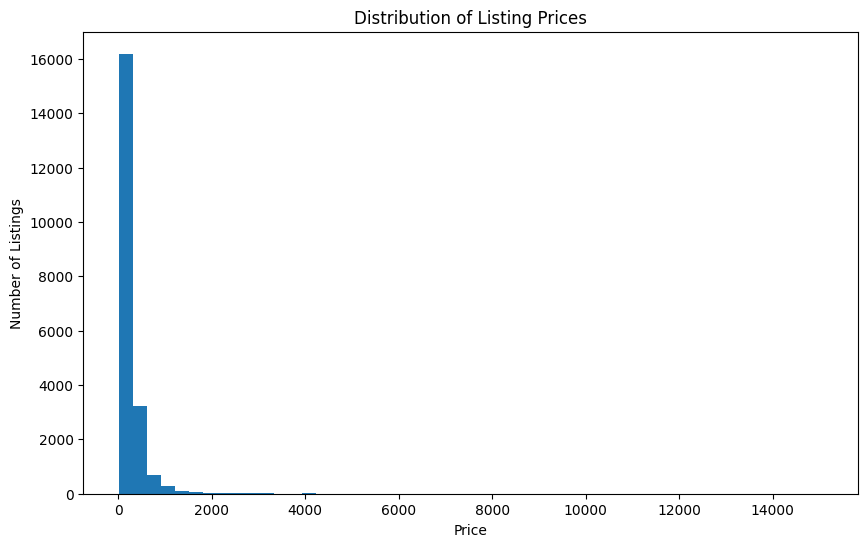

In [9]:
plt.figure(figsize=(10,6))

plt.hist(
    listings["price"].dropna(),
    bins=50
)

plt.title("Distribution of Listing Prices")

plt.xlabel("Price")

plt.ylabel("Number of Listings")

plt.show()

#  Listings by Room Type

This section shows the number of listings available for each room type.

In [10]:
room_counts = listings["room_type"].value_counts()

room_counts

room_type
Entire home/apt    18884
Private room       15519
Hotel room           371
Shared room          262
Name: count, dtype: int64

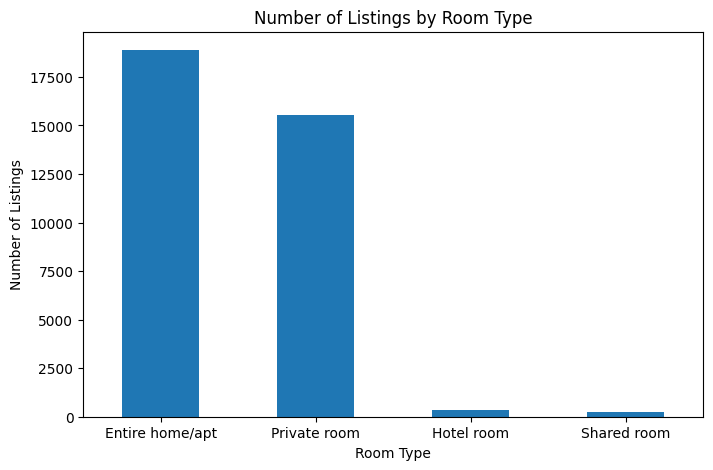

In [11]:
plt.figure(figsize=(8,5))

room_counts.plot(kind="bar")

plt.title("Number of Listings by Room Type")

plt.xlabel("Room Type")

plt.ylabel("Number of Listings")

plt.xticks(rotation=0)

plt.show()

### Observation

Private Rooms and Entire Homes dominate the dataset, while Shared Rooms and Hotel Rooms are less common.

#  Average Price by Room Type

This section compares the average listing price for each room type.

In [12]:
avg_price = (
    listings
    .groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price

room_type
Hotel room         814.347771
Entire home/apt    297.973886
Private room       184.764852
Shared room        178.021186
Name: price, dtype: float64

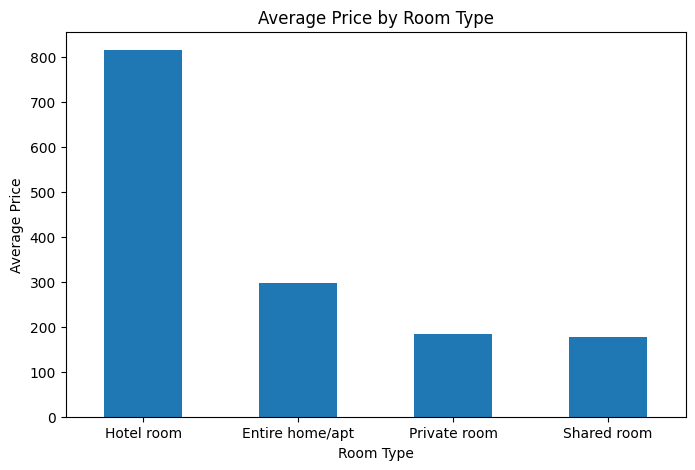

In [13]:
plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Price by Room Type")

plt.xlabel("Room Type")

plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.show()

### Observation

Entire Homes generally have the highest average prices, while Shared Rooms are the least expensive.

# Top 10 Neighborhoods by Number of Listings

In [14]:
top_neighborhoods = (
    listings["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
)

top_neighborhoods

neighbourhood_cleansed
Bedford-Stuyvesant    2408
Midtown               2037
Williamsburg          1958
Harlem                1637
Hell's Kitchen        1508
Upper West Side       1450
Upper East Side       1355
Bushwick              1278
Crown Heights         1054
East Village           893
Name: count, dtype: int64

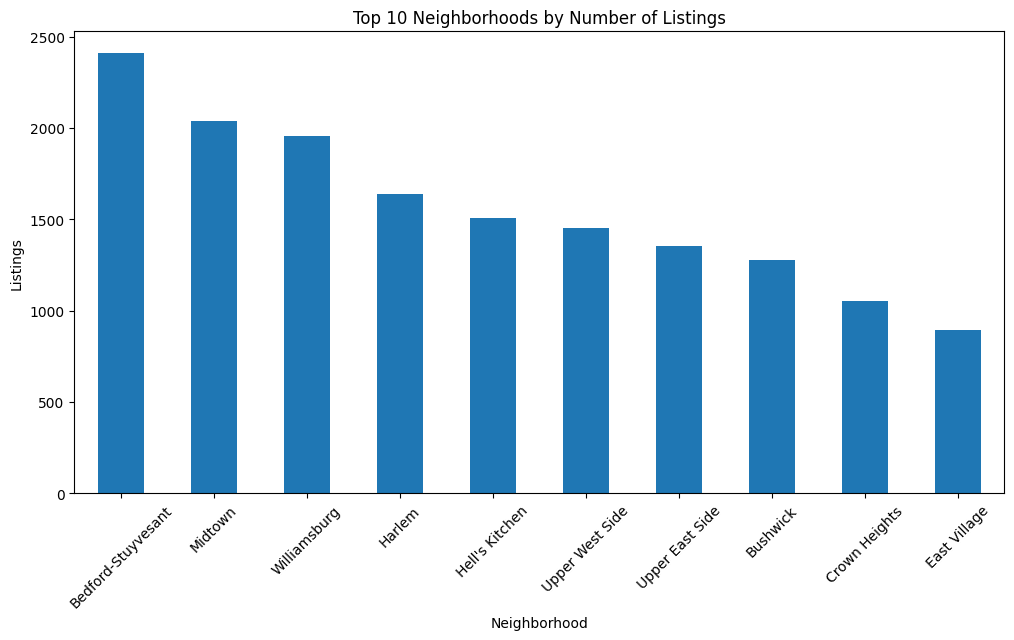

In [16]:
plt.figure(figsize=(12,6))

top_neighborhoods.plot(kind="bar")

plt.title("Top 10 Neighborhoods by Number of Listings")

plt.xlabel("Neighborhood")

plt.ylabel("Listings")

plt.xticks(rotation=45)

plt.show()

### Observation

A small number of neighborhoods contain a large proportion of Airbnb listings.

# Average Price by Neighborhood

In [17]:
avg_neighborhood_price = (
    listings
    .groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_neighborhood_price

neighbourhood_cleansed
Fort Wadsworth        1010.330000
Civic Center           862.815000
Tribeca                841.769855
Navy Yard              726.833333
Riverdale              716.173333
Country Club           647.073333
Financial District     601.806587
Battery Park City      599.634545
Brooklyn Heights       563.247500
Flatiron District      550.636341
Name: price, dtype: float64

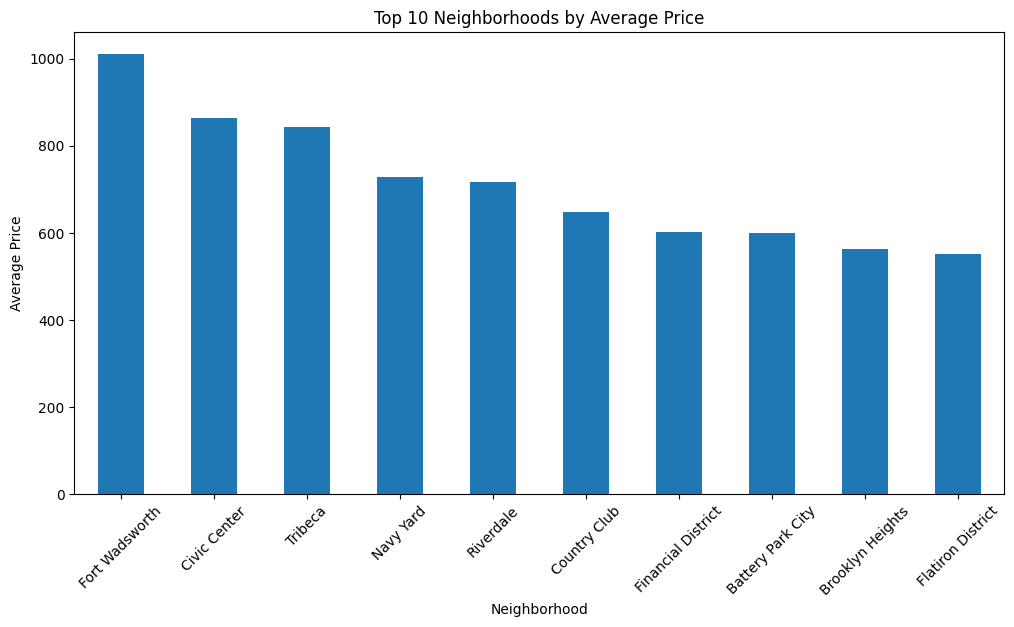

In [18]:
plt.figure(figsize=(12,6))

avg_neighborhood_price.plot(kind="bar")

plt.title("Top 10 Neighborhoods by Average Price")

plt.xlabel("Neighborhood")

plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

### Observation

Some neighborhoods command significantly higher average prices than others.

# Review Rating Distribution

In [20]:
listings["review_scores_rating"].describe()

count    24542.000000
mean         4.721852
std          0.461491
min          0.000000
25%          4.650000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

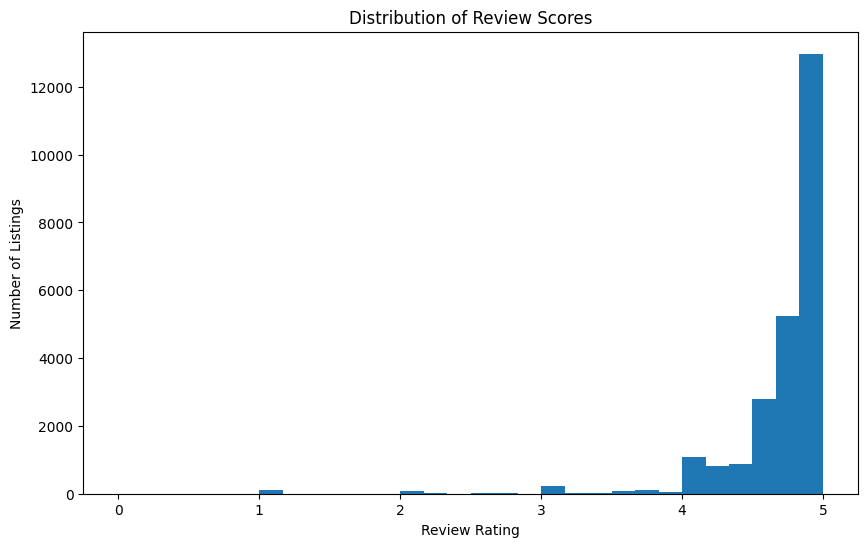

In [21]:
plt.figure(figsize=(10,6))

plt.hist(
    listings["review_scores_rating"].dropna(),
    bins=30
)

plt.title("Distribution of Review Scores")

plt.xlabel("Review Rating")

plt.ylabel("Number of Listings")

plt.show()

### Observation

Most listings receive high review ratings, indicating generally positive guest experiences.

#  Correlation Analysis

This section examines the relationships between selected numerical variables.

In [23]:
numeric_columns = [
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating"
]

correlation = listings[numeric_columns].corr()

correlation

,price,accommodates,bedrooms,beds,availability_365,number_of_reviews,review_scores_rating
price,1.000000,0.332839,0.247411,0.376448,0.045301,-0.027160,0.039138
accommodates,0.332839,1.000000,0.628848,0.678986,0.110261,0.012944,-0.009834
bedrooms,0.247411,0.628848,1.000000,0.666846,0.070415,-0.061296,0.026045
beds,0.376448,0.678986,0.666846,1.000000,0.008689,-0.037243,-0.004657
availability_365,0.045301,0.110261,0.070415,0.008689,1.000000,0.075382,-0.065653
number_of_reviews,-0.027160,0.012944,-0.061296,-0.037243,0.075382,1.000000,0.058954
review_scores_rating,0.039138,-0.009834,0.026045,-0.004657,-0.065653,0.058954,1.000000


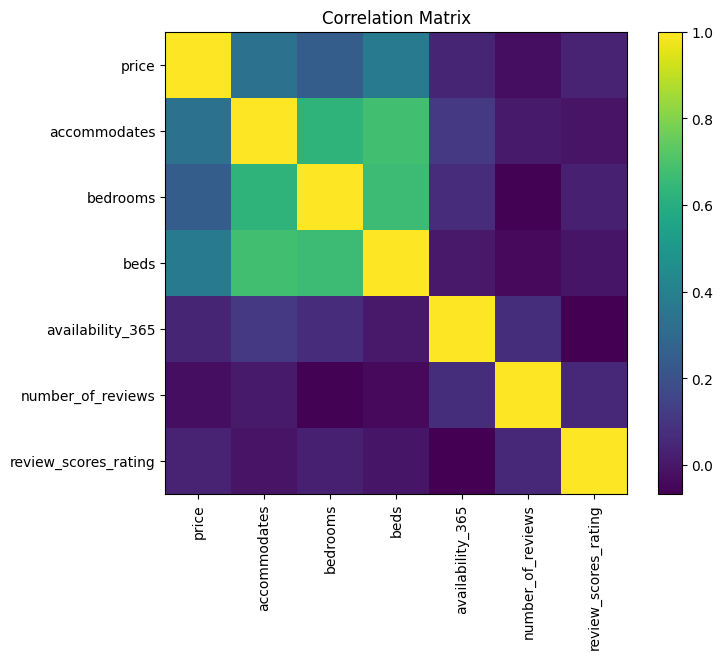

In [24]:
plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation matrix helps identify relationships between numerical variables such as price, accommodation capacity, availability, and review scores.

#  Key Findings

- Most Airbnb listings are Private Rooms and Entire Homes.
- Entire Homes have the highest average prices.
- Listing prices are highly right-skewed.
- Review ratings are generally high across listings.
- A relatively small number of neighborhoods contain the majority of listings.
- Neighborhoods vary considerably in average listing prices.